In [ ]:
#-------------------------------------------------------------------------------
# Preparación del entorno
#-------------------------------------------------------------------------------

# - Importación de las librerías y métodos necesarios
#   - Cálculos numéricos
import numpy as np

#   - Gráficos
import matplotlib.pyplot as plt

#   - Núcleo de PyTorch
#    (capas, modelos, optimizadores y funciones)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

#   - Datasets y transformaciones de imágenes
import torchvision.datasets as datasets
import torchvision.transforms as transforms

#   - Iteradores por batches
from torch.utils.data import DataLoader

#   - Imprimir datos del modelo
from torchsummary import summary

import copy
import os

# - Declaración de constantes de configuración

#   - Parápetros del DataSet
#    (Nº de img por batch, reducción de la img, Nº de clases, Nº de canales)
BATCH_SIZE = 32
RESOLUTION = 64
NUM_CLASSES = 43
NUM_CHANNELS = 3

#   - Uso de la GPU si existe
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#   - Parámetros del ataque PGD
#    (tamaño máximo de perturbación, paso por iteración, número de iteraciones)
EPSILON_RANGE = [0.01, 0.03, 0.05, 0.10, 0.20]
STEPS = 10

#   - Parámetros de la arquitectura del modelo CNN
#    (Nº cat. maps, Nº neuronas FC, pooling, dim. filtros, dim. final cat. maps)
NUM_CAT_MAP1 = 64
NUM_CAT_MAP2 = 128
NUM_CAT_MAP3 = 128
NUM_NEUR_FC = 128
POOLING1 = 2
POOLING2 = 2
POOLING3 = 2
KERNEL1 = 3
KERNEL2 = 3
KERNEL3 = 3
DIMS = ((RESOLUTION // POOLING1) // POOLING2) // POOLING3

#   - Parámetros de entrenamiento del modelo
#    (Nº de epocas de entrenamiento, tasa de aprendizaje e inercia del SGD)
EPOCHS = 10
LR = 0.01
MOMENTUM = 0.9

FIG_SIZE_X = 10
FIG_SIZE_Y = 10

In [ ]:
#-------------------------------------------------------------------------------
# Carga de los datos
#-------------------------------------------------------------------------------

# - Función para reducir y unificar la resolución de las imágenes
transform = transforms.Compose([
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor()
])

# - Descarga de los Dataset de señales de tráfico
train_data = datasets.GTSRB(root="./data",
                            split="train",
                            download=True,
                            transform=transform)
test_data = datasets.GTSRB(root="./data",
                           split="test",
                           download=True,
                           transform=transform)

# - Transformación de los dataset en batches iterables
train_loader = DataLoader(train_data,
                          batch_size=BATCH_SIZE,
                          shuffle=True)
test_loader = DataLoader(test_data,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

100%|██████████| 187M/187M [00:19<00:00, 9.50MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 8.92MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 212kB/s]


In [ ]:
#-------------------------------------------------------------------------------
# Definición de la clase CNN
#-------------------------------------------------------------------------------

# - Clase CNN hija de la clase nn.Module de PyTorch
class CNN(nn.Module):
    # --------------------------------------------------------------------------
    # Constructor
    # --------------------------------------------------------------------------
    # - Establece el número de clases de salida
    def __init__(self,
                 num_classes = NUM_CLASSES,
                 num_channels = NUM_CHANNELS,
                 num_cat_map1 = NUM_CAT_MAP1,
                 num_cat_map2 = NUM_CAT_MAP2,
                 num_cat_map3 = NUM_CAT_MAP3,
                 num_neur_fc = NUM_NEUR_FC,
                 pooling1 = POOLING1,
                 pooling2 = POOLING2,
                 pooling3 = POOLING3,
                 kernel1 = KERNEL1,
                 kernel2 = KERNEL2,
                 kernel3 = KERNEL3,
                 dims = DIMS):
        # -Inicializa la clase padre
        super().__init__()

        # Capas Convolucionales:
        self.features = nn.Sequential(
            # 1ª Capa Convolucional:
              # - Entrada: 3 canales (RGB)
              # - Salida: NºcategoryMaps
              # - Filtro: 3x3
              # - Función de activación: ReLU
              # - Agrupación: MaxPooling, reduce el tamaño a la mitad
            nn.Conv2d(num_channels,
                      num_cat_map1,
                      kernel_size=kernel1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(pooling1),

            # 2ª Capa Convolucional:
              # - Entrada: NºcategoryMaps
              # - Salida: NºcategoryMaps
              # - Filtro: 3x3
              # - Función de activación: ReLU
              # - Agrupación: MaxPooling, reduce el tamaño a la mitad
            nn.Conv2d(num_cat_map1,
                      num_cat_map2,
                      kernel_size=kernel2,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(pooling2),

            # 3ª Capa Convolucional:
              # - Entrada: NºcategoryMaps
              # - Salida: NºcategoryMaps
              # - Filtro: 3x3
              # - Función de activación: ReLU
              # - Agrupación: MaxPooling, reduce el tamaño a la mitad
            nn.Conv2d(num_cat_map2,
                      num_cat_map3,
                      kernel_size=kernel3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(pooling3)
        )

        # Clasificador:
        self.classifier = nn.Sequential(
            # 1ª Capa FullConnected:
              # - Entrada: Flatten(Nºcanales * dimCategoryMaps^2)
              # - Salida: NºneuronasFC
              # - Función de activación: ReLU
              # - Dropout: Apaga aleatoriamente el 30% de las neuronas
            nn.Flatten(),
            nn.Linear(num_cat_map3 * int(dims) * int(dims), num_neur_fc),
            nn.ReLU(),
            nn.Dropout(0.3),
            # 2ª Capa FullConnected:
              # - Entrada: 128 neuronas FC
              # - Salida: 43 Clases
            nn.Linear(num_neur_fc, num_classes)
        )

    # --------------------------------------------------------------------------
    # Definición del flujo
    # --------------------------------------------------------------------------
    # - Se establecen 1º las convoluciones y 2º la clasificación.
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función de entrenamiento
# ------------------------------------------------------------------------------

def train_model(model,
                loader,
                lossFunc,
                lr = LR,
                momentum = MOMENTUM,
                epochs = EPOCHS,
                device = DEVICE):

    # - Se inicializa el optimizador de descenso por gradiente estocástico
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    # - Bucle de entrenamiento para cada época
    for epoch in range(epochs):

        # - Se pone el modo entrenamiento del modelo
        model.train()

        # - Se inicializan las variables de métricas
          # - Pérdida acumulada
          # - Número de aciertos
          # - Número total de ejemplos
        running_loss = 0
        total, correct = 0, 0

        # - Se separan los datos de los lotes en tensores y etiquetas
        for images, labels in loader:

            # - Se mueven los datos a la GPU si el hardware lo permite
            images = images.to(device)
            labels = labels.to(device)

            # - Se reinicia el gradiente
            optimizer.zero_grad()

            # - Se calculan las predicciones y la función de pérdida
            outputs = model(images)
            loss = lossFunc(outputs, labels)

            # - Se calculan con backpropagation los gradientes de los parámetros
            loss.backward()
            optimizer.step()

            # - Se actualizan los pesos y se acumula la pérdida total del batch
            running_loss += loss.item() * images.size(0)

            # - Se obtiene las clases con los scores y el índice del mayor valor
            _, pred = torch.max(outputs, 1)

            # - Se actualiza el contador total de ejemplos y el de aciertos
            total += labels.size(0)
            correct += (pred == labels).sum().item()

        # - Se calcula el porcentaje de actiertos final de la época y se imprime
        acc = 100 * correct / total
        print(f"[NORMAL] Epoch {epoch+1} | Loss {running_loss/total:.4f} | Acc {acc:.2f}%")

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función de generación de ejemplos con FGSM
# ------------------------------------------------------------------------------

def fgsm_attack_batch(model,
                      images,
                      labels,
                      eps):

    # - Se pone el modo evaluación del modelo
    was_training = model.training
    model.eval()

    # - Se rompe el grafo, evitando fuga de memoria
    images = images.detach()

    # - Se establece que se quiere calcular gradiente respecto a la imagen
    images.requires_grad_(True)

    # - Se calcula la función de pérdida respecto a etiquetas reales
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)

    # - Se calcula el gradiente y se obtiene su dirección
    grad = torch.autograd.grad(loss, images)[0]

    # - Se genera la perturbación adversaria
    adv = images + eps * grad.sign()

    # - Se genera el ejemplo adversario y se rompe el grafo
    adv = torch.clamp(adv, 0, 1).detach()

    # - Se restaura el estado original del modelo
    if was_training:
        model.train()

    return adv

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función de generación de ejemplos con PGD
# ------------------------------------------------------------------------------

def pgd_attack_batch(model,
                     images,
                     labels,
                     eps,
                     steps = STEPS):

    # - Se pone el modo evaluación del modelo
    was_training = model.training
    model.eval()

    # - Se inicializa Alpha en relación al valor de Épsilon
    alpha = eps/steps

    # - Se rompe el grafo, evitando fuga de memoria
    images = images.detach()

    # - Se inicializa aleatoriamente dentro de valores válidos de imagen
    adv = images + torch.empty_like(images).uniform_(-eps, eps)
    adv = torch.clamp(adv, 0, 1)

    for _ in range(steps):
        # - Se establece que se quiere calcular gradiente respecto a la imagen
        adv.requires_grad_(True)

        # - Se calcula la función de pérdida respecto a etiquetas reales
        outputs = model(adv)
        loss = F.cross_entropy(outputs, labels)

        # - Se calcula el gradiente y se obtiene su dirección
        grad = torch.autograd.grad(loss, adv)[0]
        adv = adv + alpha * grad.sign()

        # - Se genera perturbación con ascenso por grad. proyectado en épsilon
        delta = torch.clamp(adv - images, -eps, eps)

        # - Se genera el ejemplo adversario y se rompe el grafo
        adv = torch.clamp(images + delta, 0, 1).detach()

    # - Se restaura el estado original del modelo
    if was_training:
        model.train()

    return adv

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función de Entrenamiento Adversario
# ------------------------------------------------------------------------------

def train_adversarial(model,
                      loader,
                      lossFunc,
                      eps,
                      pgd = False,
                      lr = LR,
                      momentum = MOMENTUM,
                      epochs = EPOCHS,
                      device = DEVICE,
                      adv_ratio=0.5):
    # - Se inicializa el modelo adversario, duplicando el modelo limpio:
    adv_model = copy.deepcopy(model).to(device)

    # - Se inicializa el optimizador de descenso por gradiente estocástico
    optimizer = optim.SGD(adv_model.parameters(), lr=lr, momentum=momentum)

    # - Bucle de entrenamiento para cada época
    for epoch in range(epochs):

        # - Se pone el modo entrenamiento del modelo
        adv_model.train()

        # - Se inicializan las variables de métricas
          # - Pérdida acumulada
          # - Número de aciertos
          # - Número total de ejemplos
        running_loss = 0
        total, correct = 0, 0

        # - Se separan los datos de los lotes en tensores y etiquetas
        for images, labels in loader:

            # - Se mueven los datos a la GPU si el hardware lo permite
            images = images.to(device)
            labels = labels.to(device)

            # - Se seleccionan índices del batches aleatorios
            batch_size = images.size(0)
            k = int(batch_size * adv_ratio)
            idx = torch.randperm(batch_size)[:k]

            # - Se clonan las imágenes, para set mixto con ejemplos adversarios
            adv_images = images.clone().detach()

            # - Se reduce epsilon en los primeros epochs para ayudar al entreno
            warmup = 0.3
            progress = min(1.0, (epoch + 1) / (epochs * warmup))
            current_eps = eps * progress

            # - Se generan ejemplos adversarios solo con parte del batch
            if pgd:
              adv_subset = pgd_attack_batch(
                adv_model,
                images[idx],
                labels[idx],
                current_eps
              )
            else:
              adv_subset = fgsm_attack_batch(
                adv_model,
                images[idx],
                labels[idx],
                current_eps
              )

            # - Se sustituyen algunas imágenes por sus respectivos ej. adv.
            adv_images[idx] = adv_subset

            # - Se reinicia el gradiente
            optimizer.zero_grad()

            # - Se calculan las predicciones y la función de pérdida
            outputs = adv_model(adv_images)
            loss = lossFunc(outputs, labels)

            # - Se calculan con backpropagation los gradientes de los parámetros
            loss.backward()
            optimizer.step()

            # - Se actualizan los pesos y se acumula la pérdida total del batch
            running_loss += loss.item() * batch_size

            # - Se obtiene las clases con los scores y el índice del mayor valor
            _, pred = torch.max(outputs, 1)

            # - Se actualiza el contador total de ejemplos y el de aciertos
            total += batch_size
            correct += (pred == labels).sum().item()

        # - Se calcula el porcentaje de actiertos final de la época y se imprime
        acc = 100 * correct / total
        print(f"[ADV {eps},", "PGD ]" if pgd else "FGSM]", f" Epoch {epoch+1} | Loss {running_loss/total:.4f} | Acc {acc:.2f}%")

    return adv_model

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función de evaluación
# ------------------------------------------------------------------------------

def evaluate(model,
             loader,
             lossFunc,
             adv = False,
             pgd = False,
             device = DEVICE):

    # - Se pone el modo evaluación del modelo
    model.eval()

    # - Se inicializan las variables de métricas
      # - Pérdida acumulada
      # - Número de aciertos
      # - Número total de ejemplos
      # - Lista de precisión por batch
    test_loss = 0
    total, correct = 0, 0
    batch_accuracies = []

    # - Se desactiva el cálculo de gradientes para agilizar la evaluación
    with torch.no_grad():

        # - Se separan los datos de los lotes en tensores y etiquetas
        for images, labels in loader:

            # - Se mueven los datos a la GPU si el hardware lo permite
            images = images.to(device)
            labels = labels.to(device)

            # - Se calculan las predicciones y la función de pérdida
            outputs = model(images)
            loss = lossFunc(outputs, labels)

            # - Se almacena el valor de la función de pérdida
            test_loss += loss.item() * images.size(0)

            # - Se obtiene las clases con los scores y el índice del mayor valor
            _, pred = torch.max(outputs, 1)

            # - Se obtiene el número de aciertos y de ejemplos del batch
            batch_correct = (pred == labels).sum().item()
            batch_total = labels.size(0)

            # - Se calcula el porcentaje accuracy por batch
            batch_acc = 100 * batch_correct / batch_total
            batch_accuracies.append(batch_acc)

            # - Se actualiza el contador total de ejemplos y el de aciertos
            total += batch_total
            correct += batch_correct

    # - Se calcula porcentaje de actiertos, media pérdida y desviación típica
    acc = 100 * correct / total
    avg_loss = test_loss / total
    std_acc = np.std(batch_accuracies)

    # - Se imprimen los resultados
    print("[ ADV ]" if adv else "[CLEAN]", ("[PGD ]" if pgd else "[FGSM]")if adv else "", " Loss:", round(avg_loss,4), "| Acc:", round(acc,2), "% | Correct:", correct, "/", total, "| Std Accuracy:", round(std_acc, 2), "%")

    return acc, std_acc

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función de Evaluación Adversaria
# ------------------------------------------------------------------------------

def evaluate_adversarial(model,
                         loader,
                         lossFunc,
                         eps,
                         adv = False,
                         pgd = False,
                         device = DEVICE):

    # - Se pone el modo evaluación del modelo
    model.eval()

    # - Se inicializan las variables de métricas
      # - Pérdida acumulada
      # - Número de aciertos
      # - Número total de ejemplos
      # - Lista de precisión por batch
    test_loss = 0
    total, correct = 0, 0
    batch_accuracies = []

    # - Se separan los datos de los lotes en tensores y etiquetas
    for images, labels in loader:

        # - Se mueven los datos a la GPU si el hardware lo permite
        images = images.to(device)
        labels = labels.to(device)

        # - Se generan los ejemplos adversarios para evaluar el modelo
        if pgd:
            adv_images = pgd_attack_batch(model, images, labels, eps)
        else:
            adv_images = fgsm_attack_batch(model, images, labels, eps)

        # - Se calculan las predicciones y la función de pérdida
        outputs = model(adv_images)
        loss = lossFunc(outputs, labels)

        # - Se almacena el valor de la función de pérdida
        test_loss += loss.item() * images.size(0)

        # - Se obtiene las clases con los scores y el índice del mayor valor
        _, pred = torch.max(outputs, 1)

        # - Se obtiene el número de aciertos y de ejemplos del batch
        batch_correct = (pred == labels).sum().item()
        batch_total = labels.size(0)

        # - Se calcula el porcentaje accuracy por batch
        batch_acc = 100 * batch_correct / batch_total
        batch_accuracies.append(batch_acc)

        # - Se actualiza el contador total de ejemplos y el de aciertos
        total += batch_total
        correct += batch_correct

    # - Se calcula porcentaje de actiertos, media pérdida y desviación típica
    acc = 100 * correct / total
    avg_loss = test_loss / total
    std_acc = np.std(batch_accuracies)

    # - Se imprimen los resultados
    print("[ ADV, " if adv else "[CLEAN,", "PGD ]" if pgd else "FGSM]", "[", eps, "] Loss:", round(avg_loss,4), "| Acc:", round(acc,2), "% | Correct:", correct, "/", total, "| Std Accuracy:", round(std_acc, 2), "%")

    return acc, std_acc

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función de Evaluación ante todos los valores de eps
# ------------------------------------------------------------------------------

def evaluate_model(model,
                   loader,
                   lossFunc,
                   adv = False,
                   pgd = False,
                   epsilon_range = EPSILON_RANGE):

    # - Se inicializan las variables que recogen las estadísticas
    FGSM_statistics = []
    PGD_statistics = []

    # - Se evalua al modelo con el conjunto de datos de prueba original
    avg, std = evaluate(model, loader, lossFunc, adv = adv)
    FGSM_statistics.append((avg, std))
    PGD_statistics.append((avg, std))

    for eps in epsilon_range:
        # - Se evalua al modelo original con el ataque FGSM
        avg, std = evaluate_adversarial(model,
                                        loader,
                                        lossFunc,
                                        eps,
                                        adv = adv,
                                        pgd = False)
        FGSM_statistics.append((avg, std))

        # - Se evalua al modelo original con el ataque PGD
        avg, std = evaluate_adversarial(model,
                                        loader,
                                        lossFunc,
                                        eps,
                                        adv = adv,
                                        pgd = True)
        PGD_statistics.append((avg, std))

    return FGSM_statistics, PGD_statistics

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función de Obtención de la imagen según índice global
# ------------------------------------------------------------------------------

def get_img_by_idx(index, loader):

    # - Se inicializa el índice actual y la imagen buscada con su label
    current_idx = 0
    target_image = None
    target_label = None

    for images, labels in loader:

        # - Para cada lote, se suma su longitud al índice actual
        batch_size = images.size(0)

        # - Si índice actual + logitud del lote > índice buscado, la imagen se
        # encuentra en el lote
        if current_idx + batch_size > index:

            # - Se calcula el índice local con la diferencia entre ambos índices
            local_idx = index - current_idx

            # - Se obtiene la imagen y etiqueta con el índice local
            target_image = images[local_idx:local_idx+1].to(DEVICE)
            target_label = labels[local_idx:local_idx+1].to(DEVICE)

            break

        # - Si no se encuentra, se suma el tamaño al índice actual y se continua
        current_idx += batch_size

    return target_image, target_label


In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función auxiliar para guardar imágenes
# ------------------------------------------------------------------------------

def save_tensor_image(tensor, path):

    # - Se elimina dimensión batch
    image = tensor.squeeze(0).detach().cpu()

    # - Se realiza la conversión
    image = image.permute(1, 2, 0).numpy()

    # - Se limita el rango
    image = image.clip(0, 1)

    # - Se guarda la imágen
    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", pad_inches=0)
    plt.close()

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función para clasificar una imagen dada
# ------------------------------------------------------------------------------

def predict_image(model, image, device=DEVICE):

    # - Se pone el modo evaluación del modelo
    model.eval()

    # - Se añade dimensión batch si no existe
    if image.dim() == 3:
        image = image.unsqueeze(0)

    # - Se mueve la imagen al dispositivo
    image = image.to(device)

    # - Se declara que no se calculan gradientes
    with torch.no_grad():

        # - Se realiza la predicción
        outputs = model(image)

        # - Se obtiene la clase con mayor probabilidad
        probs = torch.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    return f"{pred.item()}_{confidence.item():.2f}"

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la Función de Generación y guardado de ejemplos adversarios
# ------------------------------------------------------------------------------

def save_adversarial_examples(index,
                              eps_range,
                              model,
                              lossFunc,
                              loader,
                              output_dir="adv_examples"):

    # - Se crean carpetas de salida
    fgsm_dir = os.path.join(output_dir, "FGSM")
    pgd_dir = os.path.join(output_dir, "PGD")

    os.makedirs(fgsm_dir, exist_ok=True)
    os.makedirs(pgd_dir, exist_ok=True)

    # - Se pone el modelo en modo evaluación
    model.eval()

    # - Se obtiene la imagen según índice global
    target_image, target_label = get_img_by_idx(index, loader)

    # - Se valida el índice
    if target_image is None:
        raise ValueError("Índice fuera del rango del DataLoader")

    # - Se clasifica la imagen original
    original_pred = predict_image(model, target_image)

    # - Se guarda la imágen original
    save_tensor_image(target_image, os.path.join(output_dir, f"{original_pred}_original.png"))

    # - Se generan ejemplos adversarios con FGSM
    for eps in eps_range:

        adv_fgsm = fgsm_attack_batch(model, target_image, target_label, eps)
        pred = predict_image(model, adv_fgsm)
        filename = f"fgsm_eps_{eps:.3f}_{pred}.png"
        save_tensor_image(adv_fgsm, os.path.join(fgsm_dir, filename))

    # - Se generan ejemplos adversarios con PGD
    for eps in eps_range:

        adv_pgd = pgd_attack_batch(model, target_image, target_label, eps)
        pred = predict_image(model, adv_fgsm)
        filename = f"pgd_eps_{eps:.3f}_{pred}.png"
        save_tensor_image(adv_pgd, os.path.join(pgd_dir, filename))

    print("Imágenes guardadas correctamente.")

In [ ]:
# ------------------------------------------------------------------------------
# Definición de la función que imprime el gráfico que compara modelos
# ------------------------------------------------------------------------------

def plot_robustness_curves(arrays,
                           trainPGD=False,
                           pgd = False,
                           epsilonRange = EPSILON_RANGE,
                           figSizeX = FIG_SIZE_X,
                           figSizeY = FIG_SIZE_Y):

    # - Se obtienen los valores de epsilons como valores del eje X
    epsilons = np.array([0] + list(epsilonRange))

    # - Se limita el tamaño de la figura
    plt.figure(figsize=(figSizeX, figSizeY))

    # - Se obtienen los indices y los arrays de precisión
    for idx, arr in enumerate(arrays):
        arr = np.array(arr)

        # - Se obtiene media y desviación estandar de cada valor de epsilon
        avg = arr[:, 0]
        std = arr[:, 1]

        # - Se obtienen los nombres de los modelos o los labels por id
        if idx == 0:
            label = "Modelo Limpio"
            linewidth = 3.5
            zorder = 10
        else:
            eps_train = epsilonRange[idx - 1]

            if trainPGD:
                label = f"Entrenado con PGD ε={eps_train}"
            else:
                label = f"Entrenado con FGSM ε={eps_train}"

            linewidth = 2.2
            zorder = 5

        # - Se pinta la línea principal
        plt.plot(
            epsilons,
            avg,
            label=label,
            linewidth=linewidth,
            marker="o",
            markersize=4,
            zorder=zorder
        )

        # - Se pinta la banda de desviación típica
        plt.fill_between(
            epsilons,
            avg - std,
            avg + std,
            alpha=0.12
        )

    # - Se imprimen los labels de los ejes y del título
    plt.xlabel("Fuerza de atque ε",fontsize=15)
    plt.ylabel("Precisión (%)",fontsize=15)
    plt.title("Robustez frente a ataques PGD" if pgd else "Robustez frente a ataques FGSM", fontsize=15, fontweight="bold")

    # - Se estandariza la escala
    plt.ylim(0, 100)
    plt.xticks(epsilons, fontsize=12)
    plt.yticks(fontsize=12)

    # - Se define el estilo de la leyenda, cuadrícula y bordes
    plt.legend(
            fontsize=15,
            frameon=True,
            fancybox=True,
            shadow=False,
            loc="best"
    )
    plt.grid(True, linestyle="--", alpha=0.35)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # - Se definen márgenes automáticos
    plt.tight_layout()

    plt.show()

In [ ]:
# - Se inicializa el modelo y la función de pérdida
model = CNN().to(DEVICE)
lossFunc = nn.CrossEntropyLoss()

# - Se inicializan las variables que recogen las estadísticas deambos ataques
trainFGSM_advFGSM_results = []
trainFGSM_advPGD_results = []
trainPGD_advFGSM_results = []
trainPGD_advPGD_results = []

# - Se muestra un resumen del modelo
summary(model, (NUM_CHANNELS, RESOLUTION, RESOLUTION))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           1,792
              ReLU-2           [-1, 64, 64, 64]               0
         MaxPool2d-3           [-1, 64, 32, 32]               0
            Conv2d-4          [-1, 128, 32, 32]          73,856
              ReLU-5          [-1, 128, 32, 32]               0
         MaxPool2d-6          [-1, 128, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]         147,584
              ReLU-8          [-1, 128, 16, 16]               0
         MaxPool2d-9            [-1, 128, 8, 8]               0
          Flatten-10                 [-1, 8192]               0
           Linear-11                  [-1, 128]       1,048,704
             ReLU-12                  [-1, 128]               0
          Dropout-13                  [-1, 128]               0
           Linear-14                   

In [ ]:
# - Se entrena al modelo con el conjunto de datos de entrenamiento original
train_model(model, train_loader, lossFunc)

[NORMAL] Epoch 1 | Loss 2.5698 | Acc 26.22%
[NORMAL] Epoch 2 | Loss 0.8055 | Acc 73.55%
[NORMAL] Epoch 3 | Loss 0.2477 | Acc 91.93%
[NORMAL] Epoch 4 | Loss 0.1201 | Acc 96.14%
[NORMAL] Epoch 5 | Loss 0.0905 | Acc 97.25%
[NORMAL] Epoch 6 | Loss 0.0601 | Acc 98.18%
[NORMAL] Epoch 7 | Loss 0.0395 | Acc 98.79%
[NORMAL] Epoch 8 | Loss 0.0347 | Acc 98.95%
[NORMAL] Epoch 9 | Loss 0.0321 | Acc 99.05%
[NORMAL] Epoch 10 | Loss 0.0218 | Acc 99.37%


In [ ]:
# - Se evalua el modelo original
FGSM_statistics, PGD_statistics = evaluate_model(model, test_loader, lossFunc, adv = False)

# - Se guardan la media y la desviación típica para imprimir comparación
trainFGSM_advFGSM_results.append(FGSM_statistics)
trainFGSM_advPGD_results.append(PGD_statistics)
trainPGD_advFGSM_results.append(FGSM_statistics)
trainPGD_advPGD_results.append(PGD_statistics)

[CLEAN]   Loss: 0.2175 | Acc: 95.84 % | Correct: 12105 / 12630 | Std Accuracy: 3.54 %
[CLEAN, FGSM] [ 0.01 ] Loss: 3.4303 | Acc: 62.87 % | Correct: 7941 / 12630 | Std Accuracy: 8.57 %
[CLEAN, PGD ] [ 0.01 ] Loss: 3.4291 | Acc: 64.17 % | Correct: 8105 / 12630 | Std Accuracy: 8.59 %
[CLEAN, FGSM] [ 0.03 ] Loss: 9.7911 | Acc: 48.15 % | Correct: 6081 / 12630 | Std Accuracy: 8.57 %
[CLEAN, PGD ] [ 0.03 ] Loss: 15.8949 | Acc: 38.38 % | Correct: 4848 / 12630 | Std Accuracy: 8.27 %
[CLEAN, FGSM] [ 0.05 ] Loss: 13.7484 | Acc: 44.09 % | Correct: 5569 / 12630 | Std Accuracy: 8.37 %
[CLEAN, PGD ] [ 0.05 ] Loss: 29.7278 | Acc: 29.63 % | Correct: 3742 / 12630 | Std Accuracy: 7.74 %
[CLEAN, FGSM] [ 0.1 ] Loss: 19.3103 | Acc: 37.53 % | Correct: 4740 / 12630 | Std Accuracy: 8.36 %
[CLEAN, PGD ] [ 0.1 ] Loss: 64.1582 | Acc: 18.02 % | Correct: 2276 / 12630 | Std Accuracy: 7.14 %
[CLEAN, FGSM] [ 0.2 ] Loss: 23.9833 | Acc: 30.98 % | Correct: 3913 / 12630 | Std Accuracy: 8.27 %
[CLEAN, PGD ] [ 0.2 ] Loss: 1

In [ ]:
# - Se generan ejemplos adversarios de una imágen con ambos tipos de ataques
save_adversarial_examples(194, EPSILON_RANGE, model, lossFunc, test_loader)

Imágenes guardadas correctamente.


In [ ]:
# - Para cada valor del rango de epsilon se repite el mismo proceso:
for eps in EPSILON_RANGE:

    # - Se entrena al modelo con el conjunto de datos mixtos de FGSM
    adv_model = train_adversarial(model, train_loader, lossFunc, eps, pgd=False)

    # - Se evalua el modelo con entrenamiento adversario
    FGSM_statistics, PGD_statistics = evaluate_model(adv_model, test_loader, lossFunc, adv = True, pgd=False)

    # - Se guardan la media y la desviación típica para imprimir comparación
    trainFGSM_advFGSM_results.append(FGSM_statistics)
    trainFGSM_advPGD_results.append(PGD_statistics)

    # - Se entrena al modelo con el conjunto de datos mixtos de PGD
    adv_model = train_adversarial(model, train_loader, lossFunc, eps, pgd=True)

    # - Se evalua el modelo con entrenamiento adversario
    FGSM_statistics, PGD_statistics = evaluate_model(adv_model, test_loader, lossFunc, adv = True, pgd=True)

    # - Se guardan la media y la desviación típica para imprimir comparación
    trainPGD_advFGSM_results.append(FGSM_statistics)
    trainPGD_advPGD_results.append(PGD_statistics)

[ADV 0.01, FGSM]  Epoch 1 | Loss 0.1050 | Acc 96.78%
[ADV 0.01, FGSM]  Epoch 2 | Loss 0.1807 | Acc 94.29%
[ADV 0.01, FGSM]  Epoch 3 | Loss 0.2199 | Acc 92.92%
[ADV 0.01, FGSM]  Epoch 4 | Loss 0.1602 | Acc 94.75%
[ADV 0.01, FGSM]  Epoch 5 | Loss 0.1323 | Acc 95.57%
[ADV 0.01, FGSM]  Epoch 6 | Loss 0.1185 | Acc 96.05%
[ADV 0.01, FGSM]  Epoch 7 | Loss 0.1083 | Acc 96.34%
[ADV 0.01, FGSM]  Epoch 8 | Loss 0.0950 | Acc 96.78%
[ADV 0.01, FGSM]  Epoch 9 | Loss 0.0890 | Acc 97.00%
[ADV 0.01, FGSM]  Epoch 10 | Loss 0.0818 | Acc 97.31%
[ ADV ] [FGSM]  Loss: 0.1881 | Acc: 95.78 % | Correct: 12097 / 12630 | Std Accuracy: 3.33 %
[ ADV,  FGSM] [ 0.01 ] Loss: 1.0497 | Acc: 79.96 % | Correct: 10099 / 12630 | Std Accuracy: 7.23 %
[ ADV,  PGD ] [ 0.01 ] Loss: 0.9367 | Acc: 81.83 % | Correct: 10335 / 12630 | Std Accuracy: 7.07 %
[ ADV,  FGSM] [ 0.03 ] Loss: 3.7777 | Acc: 55.45 % | Correct: 7003 / 12630 | Std Accuracy: 8.75 %
[ ADV,  PGD ] [ 0.03 ] Loss: 5.2094 | Acc: 52.29 % | Correct: 6604 / 12630 | Std 

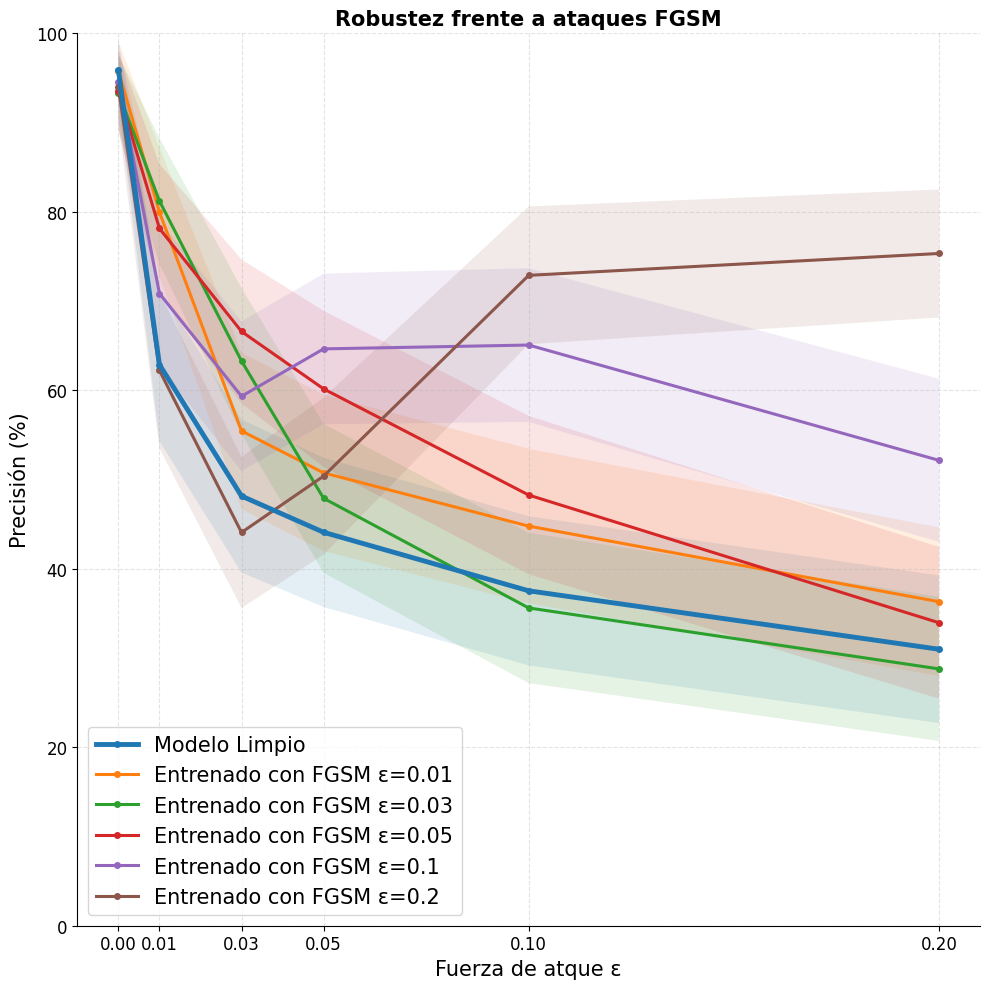

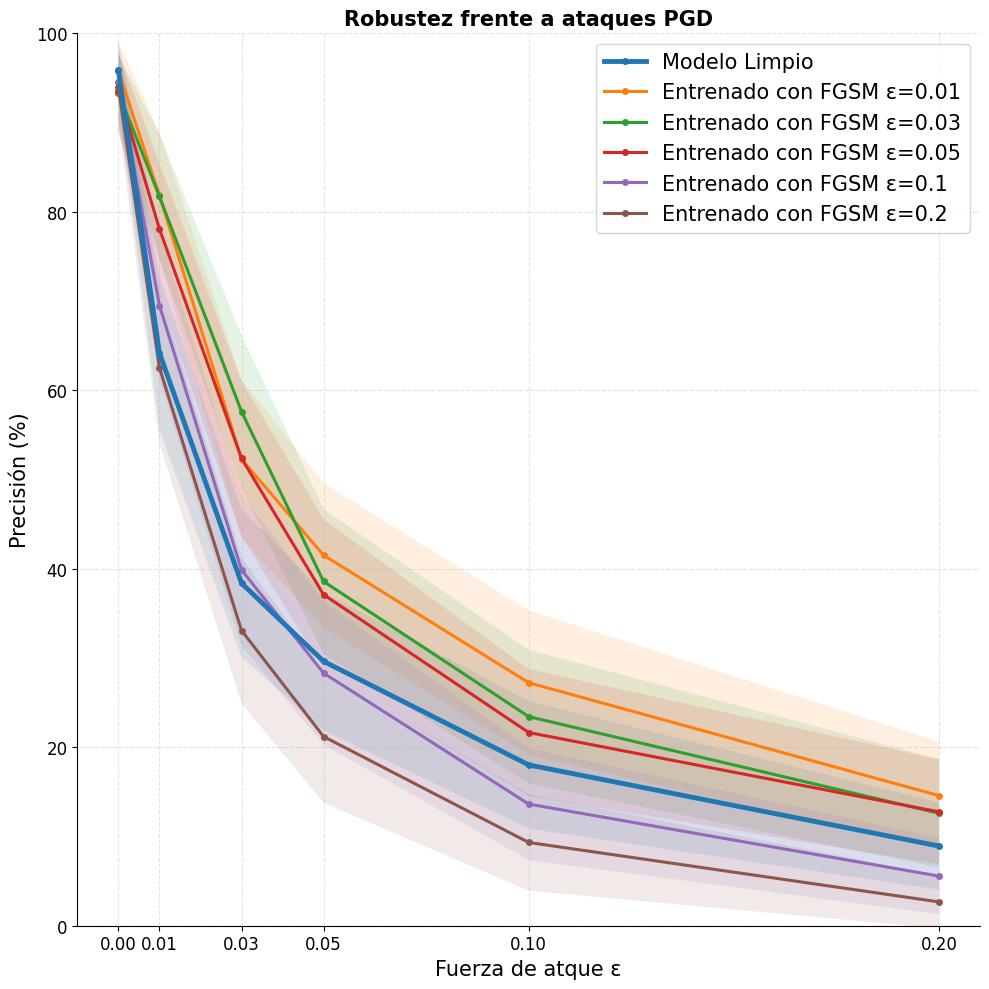

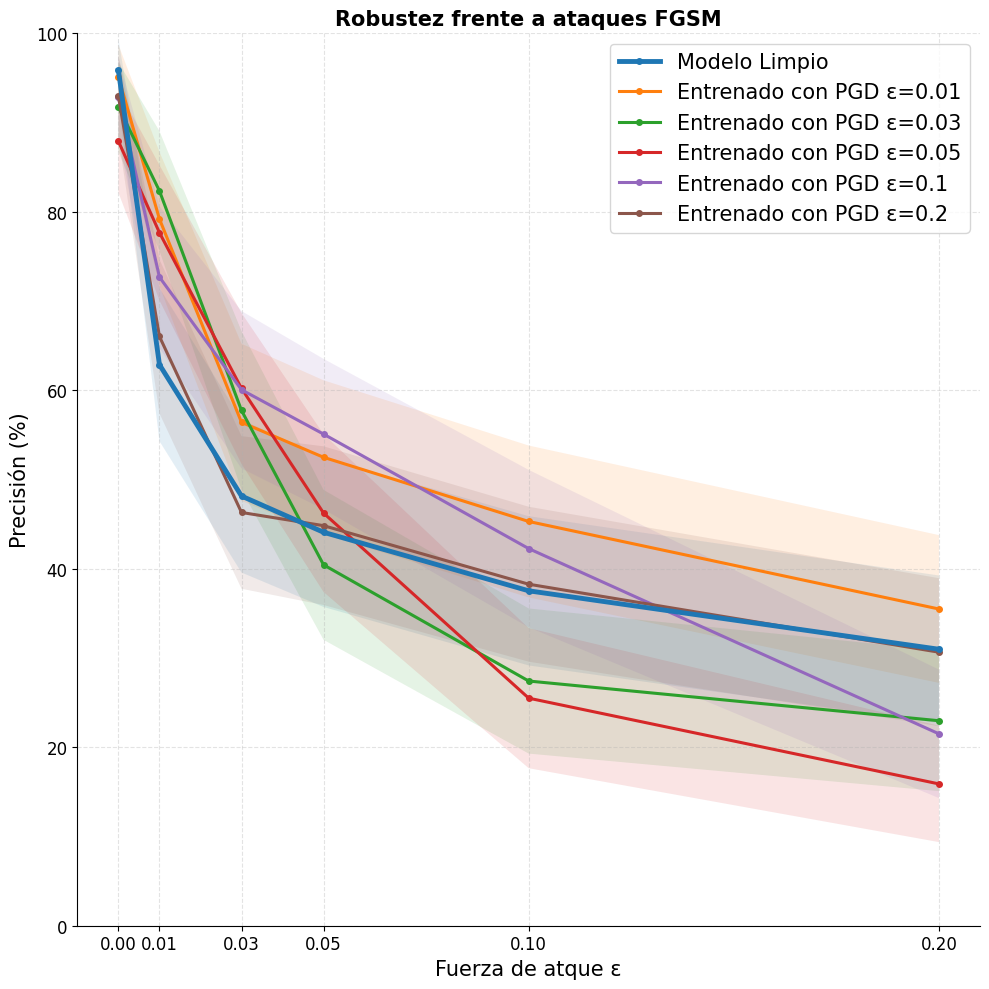

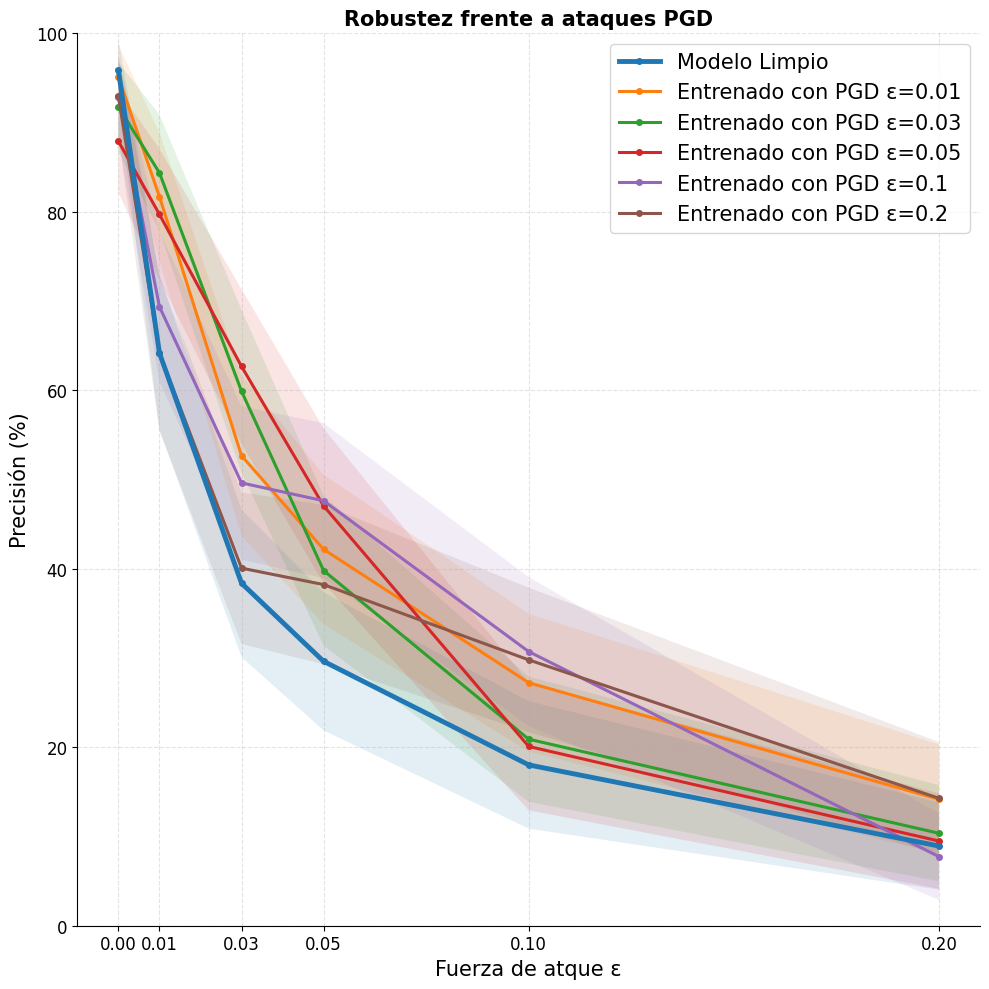

In [ ]:
# - Se muestran dos gráficos comparando en ambos ataques, el modelo original con
# los entrenados adv.
plot_robustness_curves(trainFGSM_advFGSM_results, trainPGD=False, pgd = False)
plot_robustness_curves(trainFGSM_advPGD_results, trainPGD=False, pgd = True)
plot_robustness_curves(trainPGD_advFGSM_results, trainPGD=True, pgd = False)
plot_robustness_curves(trainPGD_advPGD_results, trainPGD=True, pgd = True)